#Client Segmentation with Embeddings (PCA + Clustering)

Segment banking clients using dialog embeddings and transactional targets to uncover behavior groups that can inform retention strategy.

**Data**
- `detail/*.parquet`: dialog/embedding-level events (includes 768-dim embedding vectors)
- `targets/*.parquet`: monthly target labels per client (target_1 … target_4, trans_count, diff_trans_date)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Load & Extract

In [ ]:
!pip install datasets
from datasets import load_dataset


In [ ]:
ds = load_dataset("ai-lab/MBD-mini")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

client_split.tar.gz:   0%|          | 0.00/4.18M [00:00<?, ?B/s]

detail.tar.gz:   0%|          | 0.00/1.97G [00:00<?, ?B/s]

ptls.tar.gz:   0%|          | 0.00/1.40G [00:00<?, ?B/s]

targets.tar.gz:   0%|          | 0.00/7.93M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
print(ds)


DatasetDict({
    train: Dataset({
        features: ['c000.snappy.parquet', '__key__', '__url__'],
        num_rows: 3820
    })
})


In [ ]:
!pip install datasets --quiet

In [ ]:
# Load datasets
detail_dataset = load_dataset("ai-lab/MBD-mini", data_files="detail.tar.gz")["train"]
targets_dataset = load_dataset("ai-lab/MBD-mini", data_files="targets.tar.gz")["train"]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
import pandas as pd

# Convert to pandas
detail_df = detail_dataset.to_pandas()
targets_df = targets_dataset.to_pandas()

# Check column names and types
print("Detail Columns:", detail_df.columns.tolist())
print("Targets Columns:", targets_df.columns.tolist())

Detail Columns: ['c000.snappy.parquet', '__key__', '__url__']
Targets Columns: ['c000.snappy.parquet', '__key__', '__url__']


Check for nulls

In [ ]:
# Null values check
print("\n Nulls in detail:")
print(detail_df.isnull().sum())

print("\n Nulls in targets:")
print(targets_df.isnull().sum())

# Preview datasets
detail_df.head(), targets_df.head()


 Nulls in detail:
c000.snappy.parquet    0
__key__                0
__url__                0
dtype: int64

 Nulls in targets:
c000.snappy.parquet    0
__key__                0
__url__                0
dtype: int64


(                                 c000.snappy.parquet  \
 0  b'PAR1\x15\x04\x15\xb8)\x15\xc0)\x15\x86\x99\x...   
 1  b'PAR1\x15\x04\x15\xd0p\x15\xdcp\x15\xd3\xf9\x...   
 2  b'PAR1\x15\x04\x15\xe8s\x15\xf2s\x15\xd2\xe6\x...   
 3  b'PAR1\x15\x04\x15\xa0j\x15\xaaj\x15\xba\x9d\x...   
 4  b'PAR1\x15\x04\x15\xa8k\x15\xb2k\x15\xc2\xcd\x...   
 
                                              __key__  \
 0  detail/dialog/fold=0/part-00098-b8643b72-b2d8-...   
 1  detail/dialog/fold=0/part-00099-b8643b72-b2d8-...   
 2  detail/dialog/fold=0/part-00100-b8643b72-b2d8-...   
 3  detail/dialog/fold=0/part-00101-b8643b72-b2d8-...   
 4  detail/dialog/fold=0/part-00102-b8643b72-b2d8-...   
 
                                              __url__  
 0  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 1  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 2  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 3  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 4  /root/.cache/huggingface/hub

In [ ]:
detail_url = "https://huggingface.co/datasets/ai-lab/MBD/resolve/main/mini/detail/part-00000.parquet"
targets_url = "https://huggingface.co/datasets/ai-lab/MBD/resolve/main/mini/targets/part-00000.parquet"


In [ ]:
detail_df.head()
targets_df.head()

,c000.snappy.parquet,__key__,__url__
0,b'PAR1\x15\x04\x15\xb0\xd2\x01\x15\xda\xcd\x01...,targets/fold=0/part-00000-44ca8b70-9d42-48f7-9...,/root/.cache/huggingface/hub/datasets--ai-lab-...
1,b'PAR1\x15\x04\x15\xd8\xf9\x01\x15\x92\xed\x01...,targets/fold=0/part-00001-44ca8b70-9d42-48f7-9...,/root/.cache/huggingface/hub/datasets--ai-lab-...
2,b'PAR1\x15\x04\x15\xb8\xe4\x01\x15\xea\xd8\x01...,targets/fold=0/part-00002-44ca8b70-9d42-48f7-9...,/root/.cache/huggingface/hub/datasets--ai-lab-...
3,b'PAR1\x15\x04\x15\xc8\xf7\x01\x15\xa0\xeb\x01...,targets/fold=0/part-00003-44ca8b70-9d42-48f7-9...,/root/.cache/huggingface/hub/datasets--ai-lab-...
4,b'PAR1\x15\x04\x15\xc8\xe6\x01\x15\xec\xda\x01...,targets/fold=0/part-00004-44ca8b70-9d42-48f7-9...,/root/.cache/huggingface/hub/datasets--ai-lab-...


In [ ]:
from huggingface_hub import hf_hub_download

targets_path = hf_hub_download(
    repo_id="ai-lab/MBD-mini",
    filename="targets.tar.gz",
    repo_type="dataset",
    local_dir="/content/drive/MyDrive/MBD-mini",
    local_dir_use_symlinks=False
)

print("Downloaded to:", targets_path)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:980: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Downloaded to: /content/drive/MyDrive/MBD-mini/targets.tar.gz


In [ ]:
import tarfile
import os

base_path = "/content/drive/MyDrive/MBD-mini"

# Extract detail and target archives if not already
for archive in ["detail.tar.gz", "targets.tar.gz"]:
    archive_path = os.path.join(base_path, archive)
    if tarfile.is_tarfile(archive_path):
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=os.path.join(base_path))
            print(f" Extracted {archive}")
    else:
        print(f" Not a valid tar.gz file: {archive_path}")


 Extracted detail.tar.gz
 Extracted targets.tar.gz


## Embedding Preparation

In [ ]:
import numpy as np

# Convert embedding strings to actual numpy arrays (if needed)
detail_df['embedding'] = detail_df['embedding'].apply(lambda x: np.array(x))

# Optional: check shape and first few vectors
print("Example embedding vector shape:", detail_df['embedding'].iloc[0].shape)
detail_df['embedding'].head()


Example embedding vector shape: (768,)


,embedding
0,"[0.39314136, -0.0361106, 0.31113446, -0.197847..."
1,"[0.30220613, -0.38150322, 0.47271872, -0.28499..."
2,"[0.5709108, -0.39508772, 0.54685795, -0.413398..."
3,"[0.23272727, -0.28448686, 0.5841493, -0.524621..."
4,"[0.31696838, -0.14973284, 0.42603743, -0.39549..."


In [ ]:
print(detail_df.columns.tolist())


['client_id', 'event_time', 'embedding']


In [ ]:
# Average embedding per client
client_embeddings = (
    detail_df.groupby('client_id')['embedding']
    .apply(lambda vectors: np.vstack(vectors).mean(axis=0))
    .reset_index()
)

print(client_embeddings.shape)
client_embeddings.head()


(39, 2)


,client_id,embedding
0,0544dc05944616d28b6f8cca24c3370d067ffc2e08ea3c...,"[0.2747113, -0.25379112, 0.43568963, -0.287109..."
1,07607a690d6880a19ca0d73d223645c5d57984e271f80e...,"[0.19200973, -0.091842145, 0.3835797, -0.12997..."
2,110beb8b4f6db04c263689e8409e46ac950484f60b8276...,"[0.29296198, -0.17251517, 0.465824, -0.3069350..."
3,27f94a7c6c0a28182d0a2ccdf2f3cc9c06ac91f17b2e25...,"[0.28749967, -0.120565414, 0.48368096, -0.3369..."
4,29f4e69e326e91efed818f1cfada28d41f942b8d086e59...,"[0.40670496, -0.25526786, 0.49852827, -0.46906..."


In [ ]:
X = np.vstack(client_embeddings['embedding'].values)
print(X.shape)


(39, 768)


Performing KMeans Clustering:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.cluster import KMeans

k = 5  # You can tune this
kmeans = KMeans(n_clusters=k, random_state=42)
client_embeddings['cluster'] = kmeans.fit_predict(X_scaled)


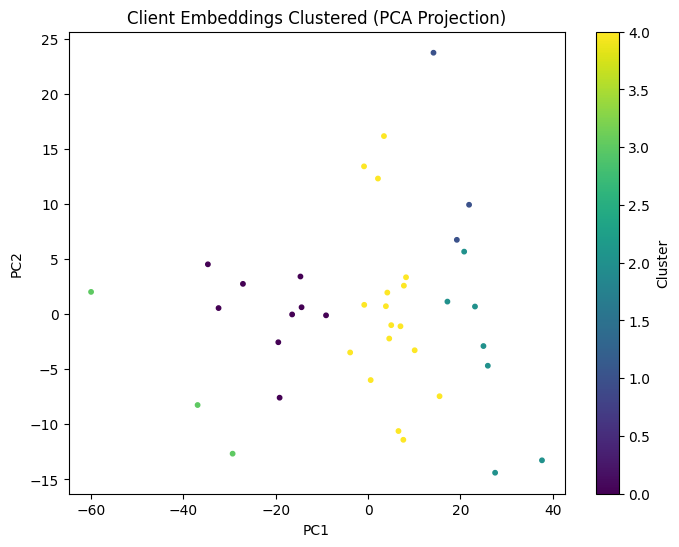

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=client_embeddings['cluster'], cmap='viridis', s=10)
plt.title("Client Embeddings Clustered (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()


we first ran K-Means, applied directly to the raw client embeddings to quickly explore whether any natural grouping patterns existed purely from the vector data. This gave us an initial sense of possible cluster structure and allowed us to visualize it using PCA without any additional features.


In [ ]:
from datasets import load_dataset
import pandas as pd

# Step 1: Get your existing client IDs
embedding_client_ids = set(client_embeddings['client_id'].astype(str))

# Step 2: Load the MBD-mini dataset
ds = load_dataset("ai-lab/MBD-mini", split="train")

# Step 3: Scan and filter matching files
matching_detail_files = []
matching_target_files = []

print("Scanning dataset for matching client IDs...")

# Iterate through the dataset rows
for i, row in enumerate(ds):
    try:
        key = row['__key__']
        parquet_bytes = row['c000.snappy.parquet']

        if 'detail/' in key:
            df = pd.read_parquet(io.BytesIO(parquet_bytes))
            file_ids = set(df['client_id'].astype(str))
            if embedding_client_ids & file_ids:
                matching_detail_files.append({'key': key, 'df': df})

        elif 'targets/' in key:
            df = pd.read_parquet(io.BytesIO(parquet_bytes))
            file_ids = set(df['client_id'].astype(str))
            if embedding_client_ids & file_ids:
                matching_target_files.append({'key': key, 'df': df})

    except Exception as e:
        print(f"Skipping row {i} due to error: {e}")

print(f"\n Found {len(matching_detail_files)} matching detail dataframes.")
print(f" Found {len(matching_target_files)} matching target dataframes.")


# Step 4: Concatenate matched dataframes
if matching_detail_files:
    full_detail_df = pd.concat([item['df'] for item in matching_detail_files], ignore_index=True)
    print(" Full detail dataframe shape:", full_detail_df.shape)
else:
    full_detail_df = pd.DataFrame()
    print(" No matching detail dataframes found.")


if matching_target_files:
    full_target_df = pd.concat([item['df'] for item in matching_target_files], ignore_index=True)
    print(" Full target dataframe shape:", full_target_df.shape)
else:
    full_target_df = pd.DataFrame()
    print(" No matching target dataframes found.")


# Step 5: Merge with embeddings
if not full_detail_df.empty and not full_target_df.empty:
    client_embeddings['client_id'] = client_embeddings['client_id'].astype(str)
    full_target_df['client_id'] = full_target_df['client_id'].astype(str)
    enriched_df = client_embeddings.merge(full_target_df, on='client_id', how='inner')

    print(" Enriched dataset shape:", enriched_df.shape)
else:
    print(" Cannot create enriched dataset: one or both dataframes are empty.")

Scanning dataset for matching client IDs...

 Found 9 matching detail dataframes.
 Found 4 matching target dataframes.
 Full detail dataframe shape: (1133762, 18)
 Full target dataframe shape: (13452, 8)
 Enriched dataset shape: (468, 10)


In [ ]:
enriched_df.iloc[0]


,0
client_id,0544dc05944616d28b6f8cca24c3370d067ffc2e08ea3c...
embedding,"[0.2747113, -0.25379112, 0.43568963, -0.287109..."
cluster,0
mon,2022-02-28
target_1,0
target_2,0
target_3,0
target_4,0
trans_count,2
diff_trans_date,0.0


We run K-Means again (after creating the enriched dataset) used embeddings combined with target and other detail data. By merging in this extra information, we could re-cluster clients with more complete behavioral and outcome context. This approach can produce clusters that are more interpretable and relevant for business insights, since the grouping considers both embedding similarity and real-world labels or features from the bank dataset.

In [ ]:
# expand the embedding list into individual columns
embedding_expanded = pd.DataFrame(enriched_df['embedding'].tolist())

# rename embedding columns for clarity
embedding_expanded.columns = [f'emb_{i}' for i in range(embedding_expanded.shape[1])]

# Combine with the original dataframe (drop the old 'embedding' column)
enriched_df = pd.concat([enriched_df.drop(columns=['embedding']), embedding_expanded], axis=1)


In [ ]:
from sklearn.preprocessing import StandardScaler

# we select embedding columns for clustering
embedding_cols = [col for col in enriched_df.columns if col.startswith('emb_')]
X = enriched_df[embedding_cols].values

#Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
print(enriched_df.shape)
enriched_df.head()

(468, 782)


,client_id,cluster,mon,target_1,target_2,target_3,target_4,trans_count,diff_trans_date,emb_0,...,emb_763,emb_764,emb_765,emb_766,emb_767,PC1,PC2,cluster_dbscan,cluster_hdbscan,cluster_agglom
0,0544dc05944616d28b6f8cca24c3370d067ffc2e08ea3c...,0,2022-02-28,0,0,0,0,2,0.0,0.274711,...,0.237337,0.152184,-0.282792,0.386618,0.329748,-16.452410,-0.032545,0,21,3
1,0544dc05944616d28b6f8cca24c3370d067ffc2e08ea3c...,0,2022-03-31,0,0,0,0,6,0.0,0.274711,...,0.237337,0.152184,-0.282792,0.386618,0.329748,-16.452427,-0.032556,0,21,3
2,0544dc05944616d28b6f8cca24c3370d067ffc2e08ea3c...,0,2022-04-30,0,0,0,0,10,0.0,0.274711,...,0.237337,0.152184,-0.282792,0.386618,0.329748,-16.452427,-0.032550,0,21,3
3,0544dc05944616d28b6f8cca24c3370d067ffc2e08ea3c...,0,2022-05-31,0,0,0,0,15,1.0,0.274711,...,0.237337,0.152184,-0.282792,0.386618,0.329748,-16.452427,-0.032550,0,21,3
4,0544dc05944616d28b6f8cca24c3370d067ffc2e08ea3c...,0,2022-06-30,0,0,0,0,18,0.0,0.274711,...,0.237337,0.152184,-0.282792,0.386618,0.329748,-16.452427,-0.032550,0,21,3


## Standardize → PCA (for visualization only)

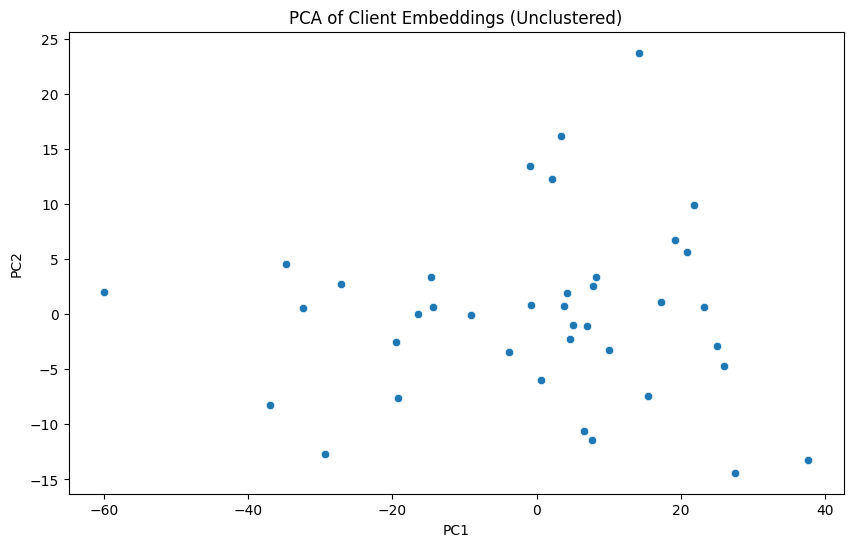

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA to 2 components for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

enriched_df['PC1'] = X_pca[:, 0]
enriched_df['PC2'] = X_pca[:, 1]

# Plot PCA result
plt.figure(figsize=(10, 6))
sns.scatterplot(data=enriched_df, x='PC1', y='PC2')
plt.title("PCA of Client Embeddings (Unclustered)")
plt.show()


## K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
enriched_df['cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, enriched_df['cluster'])
print("Silhouette Score:", score)


Silhouette Score: 0.22079125


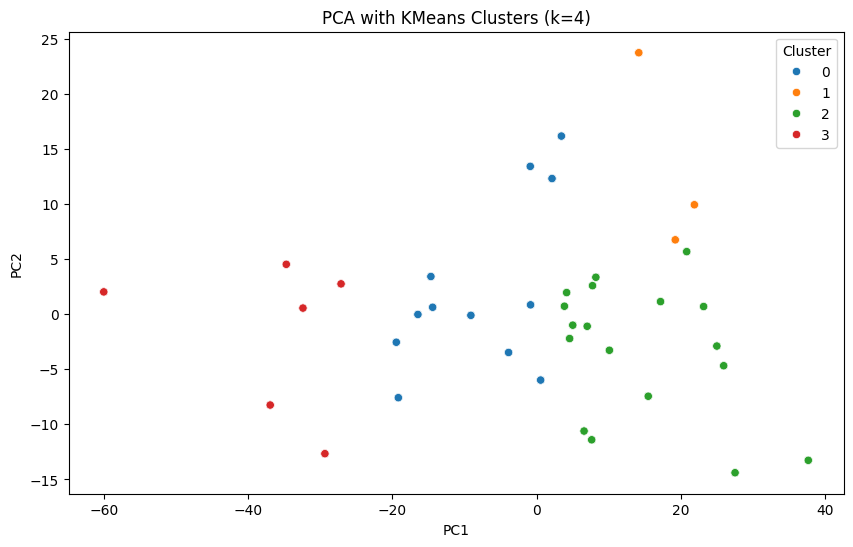

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=enriched_df, x='PC1', y='PC2', hue='cluster', palette='tab10')
plt.title(f"PCA with KMeans Clusters (k={n_clusters})")
plt.legend(title='Cluster')
plt.show()


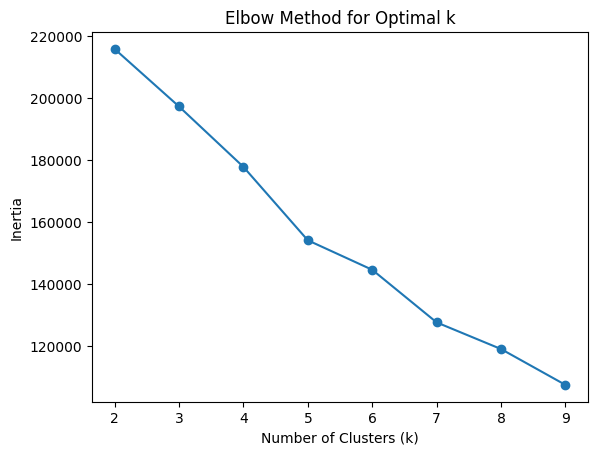

In [ ]:
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [ ]:
enriched_df.groupby('cluster')[['target_1', 'target_2', 'target_3', 'target_4']].mean()


,target_1,target_2,target_3,target_4
cluster,,,,
0,0.020833,0.0,0.006944,0.006944
1,0.000000,0.0,0.000000,0.000000
2,0.013889,0.0,0.004630,0.004630
3,0.013889,0.0,0.013889,0.000000


In [ ]:
# save to csv file
enriched_df.to_csv("clustered_clients.csv", index=False)

## Segment Profiling (Targets by Cluster)



<Axes: ylabel='cluster'>

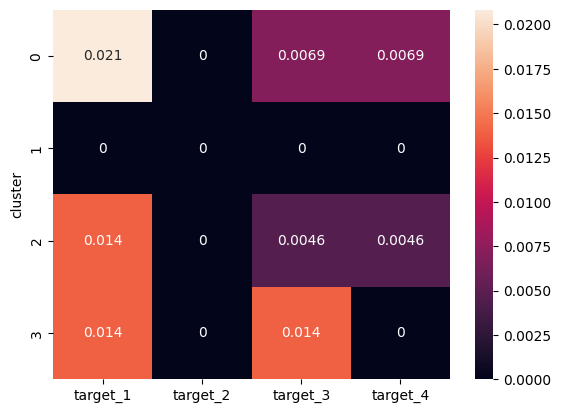

In [ ]:
import seaborn as sns
sns.heatmap(enriched_df.groupby('cluster')[['target_1', 'target_2', 'target_3', 'target_4']].mean(), annot=True)


In [ ]:
enriched_df[enriched_df['cluster'] == 0].sample(5)


,client_id,cluster,mon,target_1,target_2,target_3,target_4,trans_count,diff_trans_date,emb_0,...,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,PC1,PC2
177,6cb2db96c38c488dd0013adadc1cb25dd701dcf51ba5f5...,0,2022-11-30,0,0,0,0,277,0.0,0.217735,...,0.234832,0.697425,0.393240,0.205977,0.236731,-0.280621,0.390375,0.254869,-14.651180,3.410636
360,c0172a001e4a488f115073be2cd443b277bbe4cdddf117...,0,2022-02-28,0,0,0,0,8,0.0,0.311741,...,0.333664,0.870823,0.436090,0.220815,0.295588,-0.328056,0.417054,0.299194,-0.828649,0.840365
184,6d5b02322f361477b10c5c923d9a3f41fdbf73c674a6a6...,0,2022-06-30,0,0,0,0,224,0.0,0.223002,...,0.390001,0.963108,0.471565,0.277185,0.332745,-0.259941,0.420259,0.278031,2.145872,12.300340
302,a31262603a3300b9d282dd9afa6f9ae8b0dacd426c1056...,0,2022-04-30,0,0,0,0,182,1.0,0.271491,...,0.362879,0.675385,0.379782,0.065408,0.250685,-0.137704,0.359848,0.198564,-19.448101,-2.554588
119,54b5ff43cb464ba901cc0f9fa7361ecc8c78746c3fe487...,0,2023-01-31,0,0,0,0,644,1.0,0.205967,...,0.328488,0.709749,0.423244,0.154481,0.245264,-0.283486,0.413449,0.266373,-14.409318,0.619570


## DBSCAN/HDBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

for eps_val in [2, 4, 6, 8, 10]:
    db = DBSCAN(eps=eps_val, min_samples=3)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps_val} -> {n_clusters} clusters")


eps=2 -> 39 clusters
eps=4 -> 39 clusters
eps=6 -> 39 clusters
eps=8 -> 39 clusters
eps=10 -> 39 clusters


Silhouette Score (DBSCAN, no noise): 1.0000


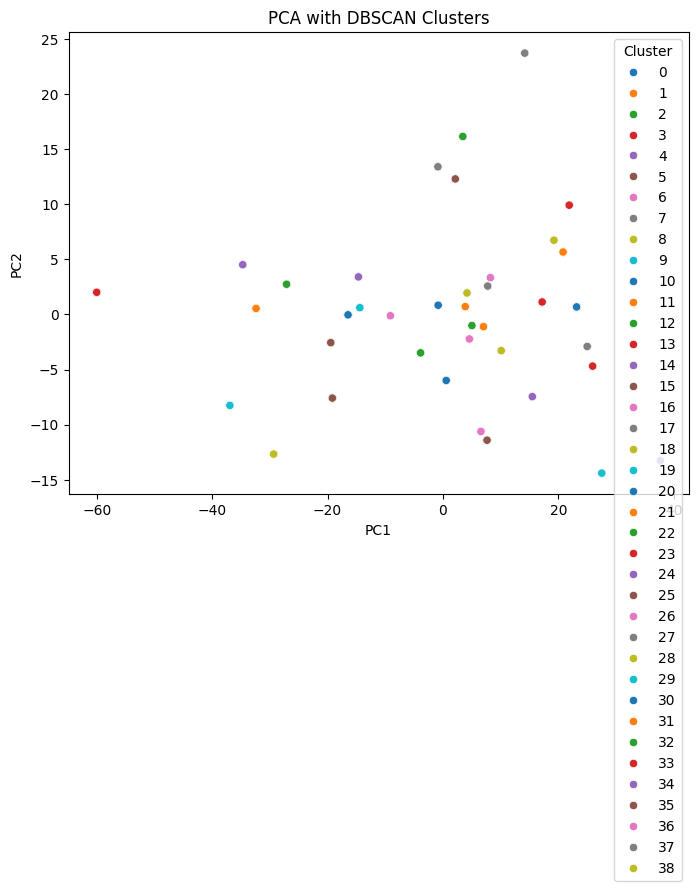

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# DBSCAN parameters (you may tweak eps & min_samples)
dbscan = DBSCAN(eps=2.5, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

# Add to dataframe
enriched_df['cluster_dbscan'] = labels

# Evaluate (ignore noise label -1)
mask = labels != -1
if sum(mask) > 0:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print(f"Silhouette Score (DBSCAN, no noise): {score:.4f}")
else:
    print("DBSCAN found only noise, no clusters.")

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=enriched_df, x='PC1', y='PC2', hue='cluster_dbscan', palette='tab10')
plt.title('PCA with DBSCAN Clusters')
plt.legend(title='Cluster')
plt.show()


In [ ]:
!pip install hdbscan

import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=5)
labels = hdb.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"HDBSCAN found {n_clusters} clusters")

# Optional: add labels to dataframe
enriched_df['cluster_hdbscan'] = labels


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 39 clusters


## Agglomerative Clustering (Ward)

Hierarchical clustering offers a complementary view without fixing “k” upfront.  
- Silhouette ≈ **0.216** (very similar to K-Means)  
- Dendrogram shows two main branches with smaller sub-clusters

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
labels = agg.fit_predict(X_scaled)
enriched_df['cluster_agglom'] = labels


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, enriched_df['cluster_agglom'])
print(f"Silhouette Score (Agglomerative): {score:.4f}")


Silhouette Score (Agglomerative): 0.2162


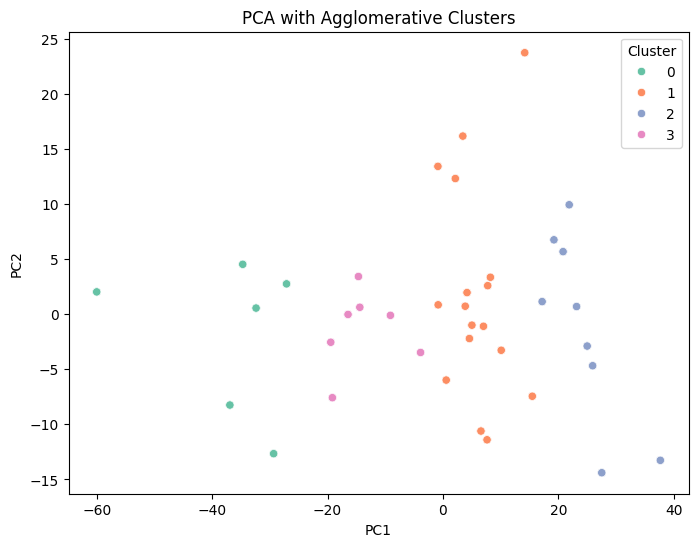

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=enriched_df, x='PC1', y='PC2', hue='cluster_agglom', palette='Set2')
plt.title("PCA with Agglomerative Clusters")
plt.legend(title='Cluster')
plt.show()


We applied KMeans and Agglomerative Clustering to group clients based on their embedded behavioral features.

KMeans with k=4 gave a Silhouette Score of 0.2209, while Agglomerative Clustering produced a comparable score of 0.2162.

DBSCAN and HDBSCAN, though density-based, failed to form meaningful clusters for this dataset.

Overall, KMeans was selected as the primary method due to its performance and simplicity, but hierarchical clustering provided valuable supporting insight.

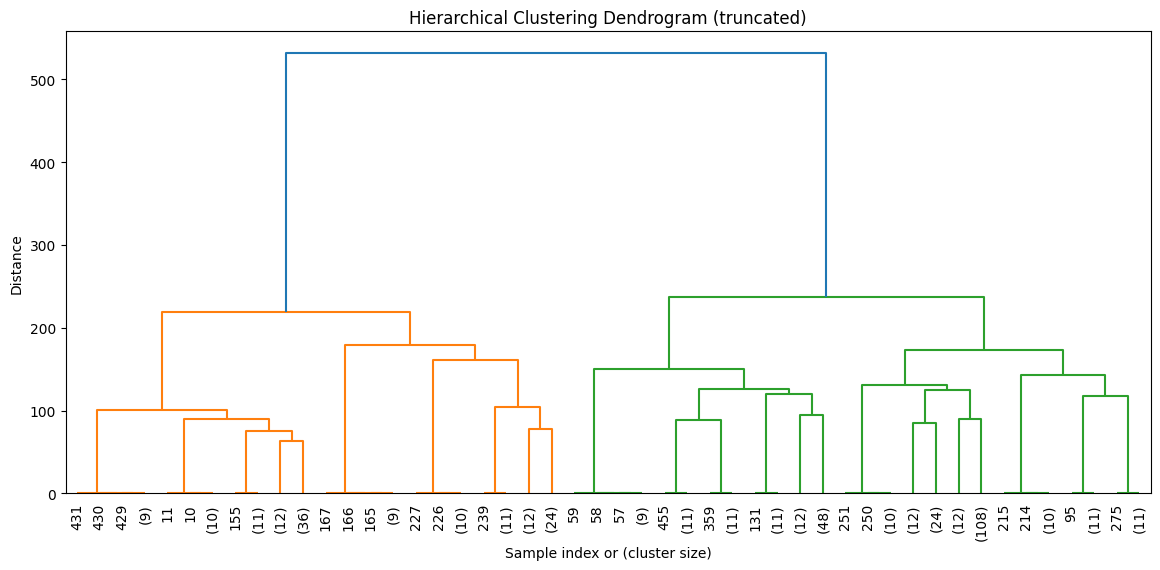

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute linkage matrix (Ward's method works well for Euclidean space)
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.show()


Hierarchical clustering dendrogram (truncated) using Ward’s linkage on PCA-reduced client embeddings. The vertical height of merges indicates inter-cluster dissimilarity. The presence of major bifurcations supports the formation of 2–4 distinct clusters.

## Exploratory Data Analysis (EDA)

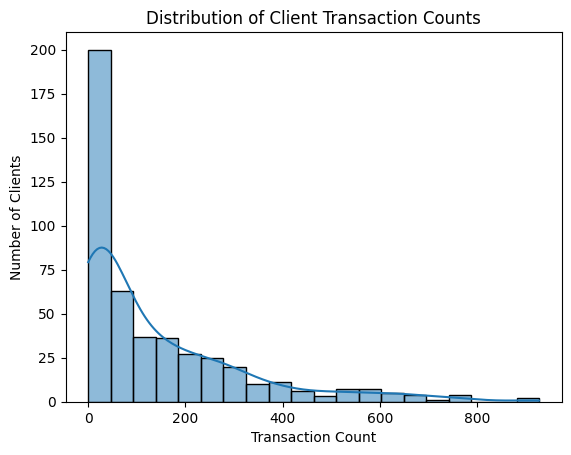

In [ ]:
sns.histplot(enriched_df['trans_count'], bins=20, kde=True)
plt.title("Distribution of Client Transaction Counts")
plt.xlabel("Transaction Count")
plt.ylabel("Number of Clients")
plt.show()


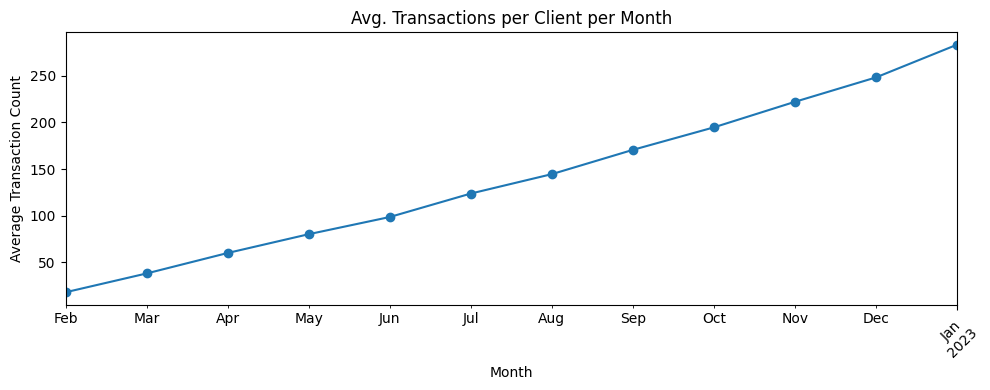

In [ ]:
enriched_df['mon'] = pd.to_datetime(enriched_df['mon'])

monthly_avg = enriched_df.groupby(enriched_df['mon'].dt.to_period("M"))['trans_count'].mean()

monthly_avg.plot(kind='line', marker='o', figsize=(10, 4), title="Avg. Transactions per Client per Month")
plt.ylabel("Average Transaction Count")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Avg. Transactions per Client per Month
The chart shows the average number of transactions per client over time, measured monthly. A steady upward trend is observed across the year, indicating growing user engagement and platform usage. This pattern suggests either client onboarding momentum or increased transaction frequency by existing clients, both of which are positive indicators of adoption and sustained usage.

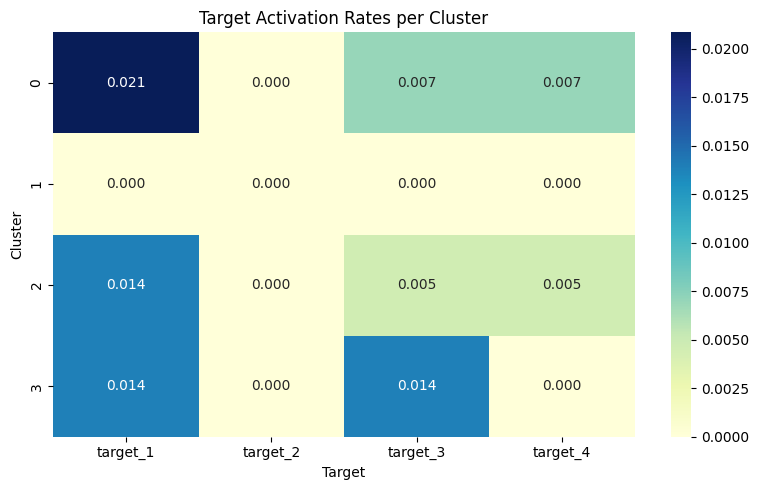

In [ ]:
import seaborn as sns

target_cols = ['target_1', 'target_2', 'target_3', 'target_4']
cluster_target_means = enriched_df.groupby('cluster')[target_cols].mean()

plt.figure(figsize=(8, 5))
sns.heatmap(cluster_target_means, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title("Target Activation Rates per Cluster")
plt.ylabel("Cluster")
plt.xlabel("Target")
plt.tight_layout()
plt.show()


The heatmap displays the proportion of clients within each cluster that triggered specific target behaviors. Notably, Cluster 0 shows a comparatively higher activation for target_1, while Cluster 3 shows more activity for both target_1 and target_3. These variations suggest that behavioral segments identified via clustering exhibit distinct propensities toward triggering certain targets, which can inform targeted interventions or personalized strategies.

/tmp/ipython-input-119936774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=enriched_df, x='cluster', y='trans_count', palette='Set2')


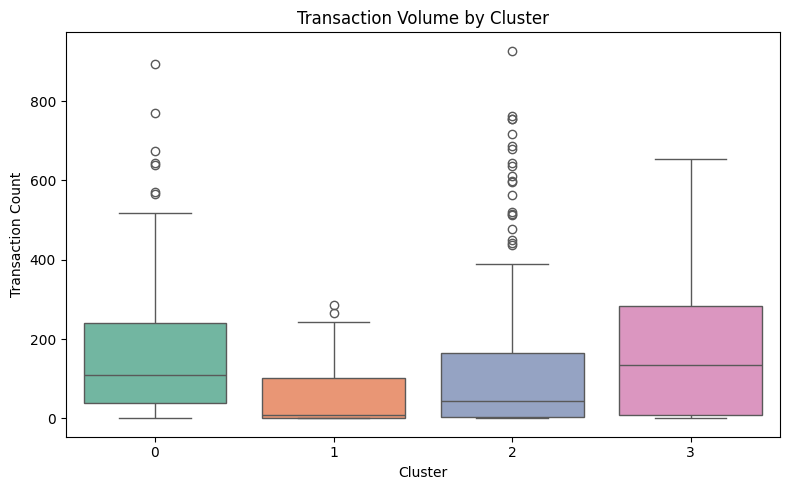

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=enriched_df, x='cluster', y='trans_count', palette='Set2')
plt.title("Transaction Volume by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()


This boxplot compares transaction volumes across clusters, revealing differences in behavioral intensity. Cluster 3 demonstrates higher median transaction activity and a wider spread, suggesting a more engaged or diverse group of clients. In contrast, Clusters 0 and 1 show lower and tighter transaction volumes. These distinctions help characterize cluster-level behavior, supporting segmentation use cases in customer profiling or retention modeling.

#THE END